# GLM-5.2 vs Claude Opus 4.8 — Benchmark Results

Two complementary benchmarks on the **same repository**, both scored against
**deterministic** ground truth (a static-analysis oracle and a real test suite):

| | Benchmark 1 — **Blast Radius** | Benchmark 2 — **Debug Loop** |
|---|---|---|
| Question | "If you rename `X`, what breaks?" | "This backend bug is reported — fix it." |
| Shape | one shot, whole repo in context | agentic: tools + iterate |
| Ground truth | `grep` find-references oracle | a real failing `pytest` (SWE-bench style) |
| Measures | long-context **retrieval** | long-context **reasoning + action** |

This notebook only *visualizes* result files. Generate them first:

```bash
python run_benchmark.py              # Benchmark 1  -> results/latest.json
python run_benchmark.py --debug-loop # Benchmark 2  -> results/debug_loop_latest.json
```

In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.titleweight": "bold"})

RESULTS = Path("results")
MODEL_COLORS = {"opus-4-8": "#C8643C", "glm-5-2": "#3C6EC8"}
COLOR = lambda k: MODEL_COLORS.get(k, "#888888")


def load(path):
    p = RESULTS / path
    if not p.exists():
        return None
    return json.loads(p.read_text(encoding="utf-8"))


single = load("latest.json")            # Benchmark 1
debug = load("debug_loop_latest.json")  # Benchmark 2

# Models that actually produced results (skip any without an API key).
RAN1 = {k: m for k, m in (single or {}).get("models", {}).items() if "aggregate" in m} if single else {}
RAN2 = {k: m for k, m in (debug or {}).get("models", {}).items() if "aggregate" in m} if debug else {}


def banner(tag, d, ran):
    if not d:
        print(f"[{tag}] no results file — run the benchmark first."); return
    syn = "  *** SYNTHETIC DEMO DATA ***" if d.get("synthetic") else ""
    print(f"[{tag}] mode={d.get('mode')}  generated={d.get('generated_at','?')[:19]}{syn}")
    print(f"        models: {', '.join(m['label'] for m in ran.values()) or '(none ran)'}")


banner("Benchmark 1 / Blast Radius", single, RAN1)
banner("Benchmark 2 / Debug Loop", debug, RAN2)

[Benchmark 1 / Blast Radius] mode=live  generated=2026-06-24T10:50:18
        models: Claude Opus 4.8, GLM-5.2
[Benchmark 2 / Debug Loop] mode=debug_loop  generated=2026-06-21T17:31:25
        models: Claude Opus 4.8, GLM-5.2


---
# Benchmark 1 — Blast Radius (long-context retrieval)

For each of 10 target symbols, each model is handed the **entire repository** (~130k
tokens) and asked to list every file+line a rename would touch. Scored against a
`grep` oracle, at **file** and **line** granularity.

In [2]:
# Oracle — the deterministic blast radius each model is scored against.
if single:
    oracle_df = (pd.DataFrame([{"symbol": s, "files": v["files"], "lines": v["lines"]}
                               for s, v in single["oracle"].items()])
                 .sort_values("lines", ascending=False).reset_index(drop=True))
    display(oracle_df)
    print(f"context: {single['repo']['n_files']} files, "
          f"~{single['repo']['est_tokens']:,} tokens")
else:
    print("No Benchmark 1 results.")

,symbol,files,lines
0,UserProfile,13,48
1,AgentState,11,45
2,RoutineProduct,8,28
3,ProductExtraction,8,20
4,SafetyAudit,7,20
5,MIN_INGREDIENTS_FOR_AUDIT,5,14
6,inci_names,5,11
7,PRODUCT_MATCH_THRESHOLD,3,10
8,build_initial_state,4,8
9,IDENTITY_CONFIDENCE_THRESHOLD,3,6


context: 62 files, ~131,669 tokens


In [3]:
# Build the per-model summary table for Benchmark 1.
if RAN1:
    rows = []
    for k, m in RAN1.items():
        a = m["aggregate"]
        rows.append({"model": m["label"], "key": k,
                     "file_F1": a["file"]["macro"]["f1"],
                     "file_precision": a["file"]["macro"]["precision"],
                     "file_recall": a["file"]["macro"]["recall"],
                     "line_F1": a["line"]["macro"]["f1"],
                     "line_precision": a["line"]["macro"]["precision"],
                     "line_recall": a["line"]["macro"]["recall"],
                     "mean_latency_s": a["latency_s_mean"],
                     "total_cost_usd": a["total_cost_usd"]})
    b1 = pd.DataFrame(rows).set_index("model")
    display(b1[["file_F1", "line_F1", "file_recall", "line_recall",
                "mean_latency_s", "total_cost_usd"]].round(3))
else:
    b1 = None
    print("No Benchmark 1 results.")

,file_F1,line_F1,file_recall,line_recall,mean_latency_s,total_cost_usd
model,,,,,,
Claude Opus 4.8,0.940,0.883,0.904,0.829,6.218,2.321
GLM-5.2,0.934,0.860,0.907,0.798,4.542,2.037


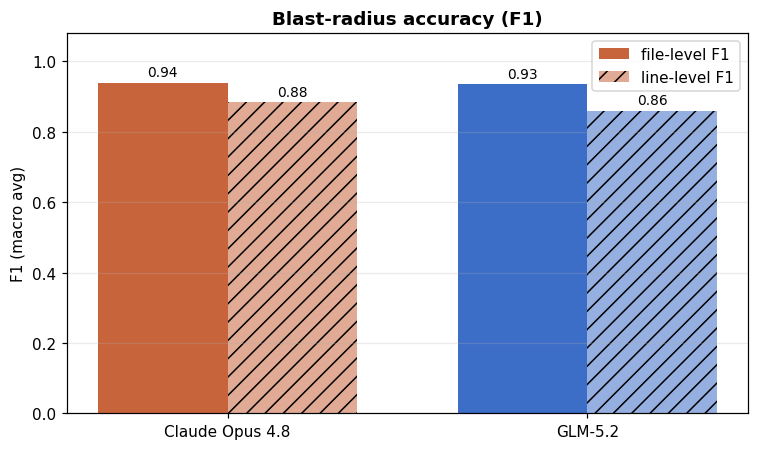

In [4]:
# Headline — file- and line-level F1 (macro-averaged across symbols).
if b1 is not None:
    fig, ax = plt.subplots(figsize=(7, 4.2))
    x = range(len(b1)); w = 0.36
    cols = [COLOR(k) for k in b1["key"]]
    ax.bar([i - w/2 for i in x], b1["file_F1"], w, color=cols, label="file-level F1")
    ax.bar([i + w/2 for i in x], b1["line_F1"], w, color=cols, alpha=0.55,
           hatch="//", label="line-level F1")
    for i, (f, l) in enumerate(zip(b1["file_F1"], b1["line_F1"])):
        ax.text(i - w/2, f + .01, f"{f:.2f}", ha="center", va="bottom", fontsize=9)
        ax.text(i + w/2, l + .01, f"{l:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(list(x)); ax.set_xticklabels(b1.index)
    ax.set_ylim(0, 1.08); ax.set_ylabel("F1 (macro avg)")
    ax.set_title("Blast-radius accuracy (F1)")
    ax.legend(); ax.grid(axis="x"); fig.tight_layout(); plt.show()

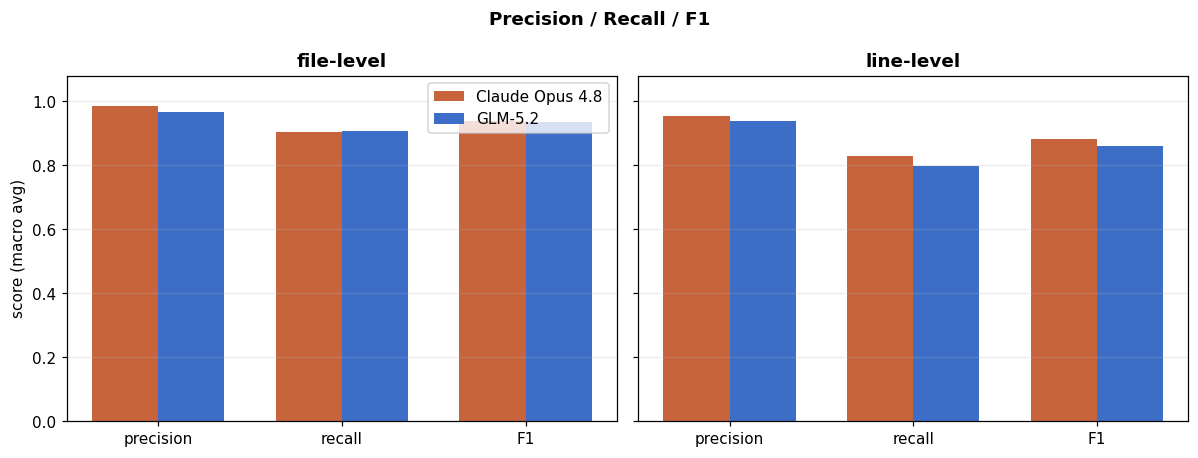

In [5]:
# Precision vs recall — file and line level side by side.
if b1 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
    for ax, lvl in zip(axes, ["file", "line"]):
        metrics = ["precision", "recall", "F1"]
        cols = [f"{lvl}_precision", f"{lvl}_recall", f"{lvl}_F1"]
        x = range(len(metrics)); w = 0.36
        for j, (model, row) in enumerate(b1.iterrows()):
            off = (j - (len(b1) - 1) / 2) * w
            ax.bar([i + off for i in x], [row[c] for c in cols], w,
                   label=model, color=COLOR(row["key"]))
        ax.set_xticks(list(x)); ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1.08); ax.set_title(f"{lvl}-level"); ax.grid(axis="x")
    axes[0].set_ylabel("score (macro avg)"); axes[0].legend()
    fig.suptitle("Precision / Recall / F1", fontweight="bold")
    fig.tight_layout(); plt.show()

C:\Users\dvall\AppData\Local\Temp\ipykernel_10200\4133184321.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=40, ha="right")


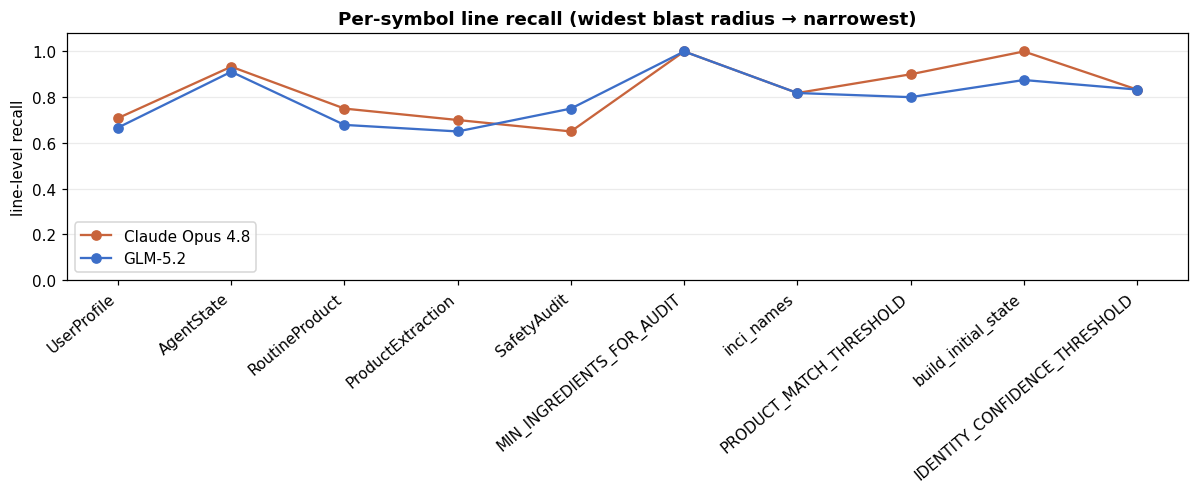

In [6]:
# Does accuracy degrade as the blast radius grows? Per-symbol line recall,
# widest symbol on the left. The stress case for a long-context model is the
# wide-blast symbol (UserProfile, AgentState): can it still find ALL 40+ refs?
if RAN1 and single:
    order = oracle_df["symbol"].tolist()
    fig, ax = plt.subplots(figsize=(11, 4.6))
    for k, m in RAN1.items():
        by = {s["symbol"]: s for s in m["per_symbol"]}
        y = [by[s]["line"]["recall"] for s in order]
        ax.plot(order, y, marker="o", color=COLOR(k), label=m["label"])
    ax.set_ylim(0, 1.08); ax.set_ylabel("line-level recall")
    ax.set_title("Per-symbol line recall (widest blast radius → narrowest)")
    ax.set_xticklabels(order, rotation=40, ha="right")
    ax.legend(); ax.grid(axis="x", alpha=0); fig.tight_layout(); plt.show()

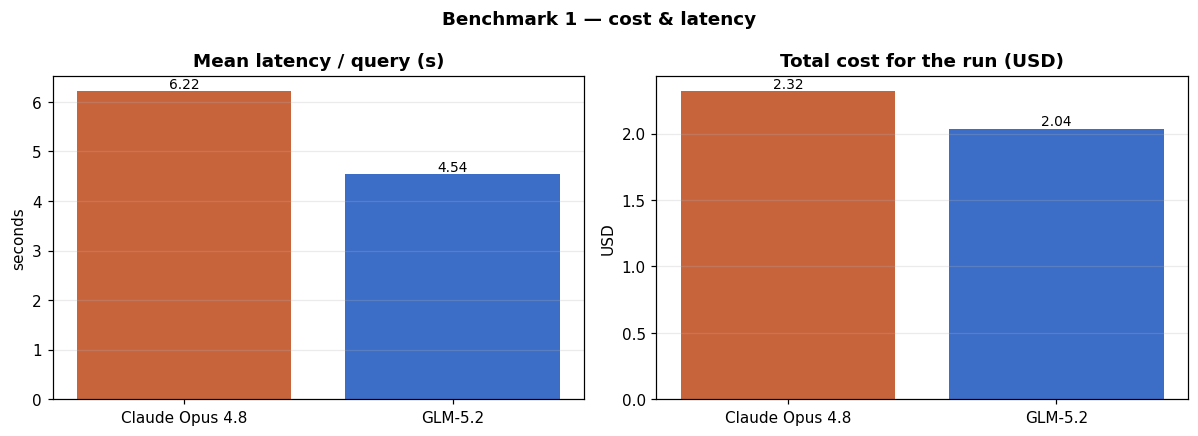

In [7]:
# The engineering trade-off: latency and cost behind that accuracy.
if b1 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    cols = [COLOR(k) for k in b1["key"]]
    axes[0].bar(b1.index, b1["mean_latency_s"], color=cols)
    axes[0].set_title("Mean latency / query (s)"); axes[0].set_ylabel("seconds")
    axes[1].bar(b1.index, b1["total_cost_usd"], color=cols)
    axes[1].set_title("Total cost for the run (USD)"); axes[1].set_ylabel("USD")
    for ax in axes:
        for i, v in enumerate(ax.containers[0].datavalues):
            ax.text(i, v, f"{v:.3g}", ha="center", va="bottom", fontsize=9)
        ax.grid(axis="x")
    fig.suptitle("Benchmark 1 — cost & latency", fontweight="bold")
    fig.tight_layout(); plt.show()
    if single.get("synthetic"):
        print("NOTE: synthetic demo — cost/latency are zero (no API calls).")

---
# Benchmark 2 — Debug Loop (agentic bug-fix)

Each model gets **tools** (`list_dir`, `read_file`, `grep`, `edit_file`, `run_tests`)
and iterates to fix a real bug in its **own isolated git worktree**, graded by a real
`pytest` run — the SWE-bench pattern.

**Scenario (commit `d11ae62`):** `POST /scan` ran the whole pipeline in one blocking
request and tripped Railway's reverse-proxy timeout. The fix adds a streaming
`POST /scan/stream` SSE endpoint. The harness checks out the buggy parent, applies only
the *test* patch, and the model must make `test_scan_stream_*` pass **without
regressing** `tests/test_api.py`.

Each model runs several independent **trials**; we report **pass@k** and efficiency
(tool calls, tokens, cost, latency).

In [8]:
# Per-model summary table for Benchmark 2.
if RAN2:
    rows = []
    for k, m in RAN2.items():
        a = m["aggregate"]
        rows.append({"model": m["label"], "key": k,
                     "trials": a["trials"], "passes": a["passes"],
                     "pass@1": a["pass_at_1"],
                     "cost_per_pass_usd": a["cost_per_pass_usd"],
                     "median_cost_usd": a["median_cost_usd"],
                     "median_tool_calls": a["median_tool_calls"],
                     "median_total_tokens": a["median_total_tokens"],
                     "median_latency_s": a["median_latency_s"],
                     "harness_errors": a["n_harness_errors"]})
    b2 = pd.DataFrame(rows).set_index("model")
    sc = debug.get("scenario", {})
    print(f"scenario: fix={sc.get('fix_commit')}  target=`{sc.get('verdict_target')}`  "
          f"trials={sc.get('trials')}  step budget={sc.get('step_budget')}")
    display(b2.drop(columns="key"))
else:
    b2 = None
    print("No Benchmark 2 results — run `python run_benchmark.py --debug-loop`.")

scenario: fix=d11ae62  target=`scan_stream`  trials=5  step budget=15


,trials,passes,pass@1,cost_per_pass_usd,median_cost_usd,median_tool_calls,median_total_tokens,median_latency_s,harness_errors
model,,,,,,,,,
Claude Opus 4.8,5,5,1.0,0.612946,0.608498,14,299605,150.85,0
GLM-5.2,5,2,0.4,1.655903,0.622563,21,401217,241.68,0


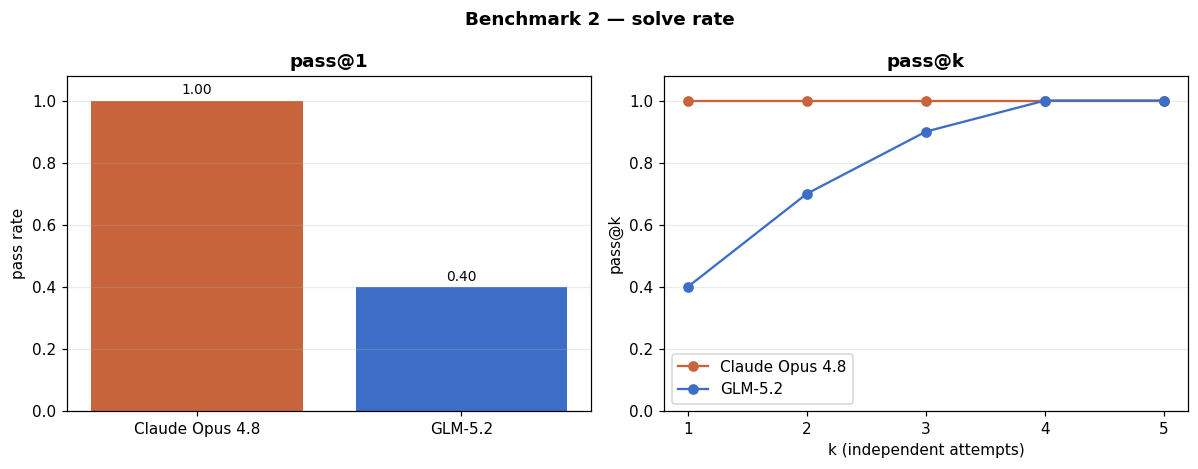

In [9]:
# pass@1 (left) and the pass@k curve (right). pass@k = probability that at least
# one of k independent attempts yields a passing fix (unbiased, Chen et al. 2021).
if b2 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
    cols = [COLOR(k) for k in b2["key"]]
    axes[0].bar(b2.index, b2["pass@1"], color=cols)
    axes[0].set_ylim(0, 1.08); axes[0].set_title("pass@1"); axes[0].set_ylabel("pass rate")
    for i, v in enumerate(b2["pass@1"]):
        axes[0].text(i, v + .01, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    axes[0].grid(axis="x")
    for k, m in RAN2.items():
        pk = m["aggregate"]["pass_at_k"]
        ks = sorted(int(i) for i in pk)
        axes[1].plot(ks, [pk[str(i)] for i in ks], marker="o",
                     color=COLOR(k), label=m["label"])
    axes[1].set_ylim(0, 1.08); axes[1].set_xlabel("k (independent attempts)")
    axes[1].set_ylabel("pass@k"); axes[1].set_title("pass@k")
    axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    axes[1].legend(); axes[1].grid(axis="x", alpha=0)
    fig.suptitle("Benchmark 2 — solve rate", fontweight="bold")
    fig.tight_layout(); plt.show()

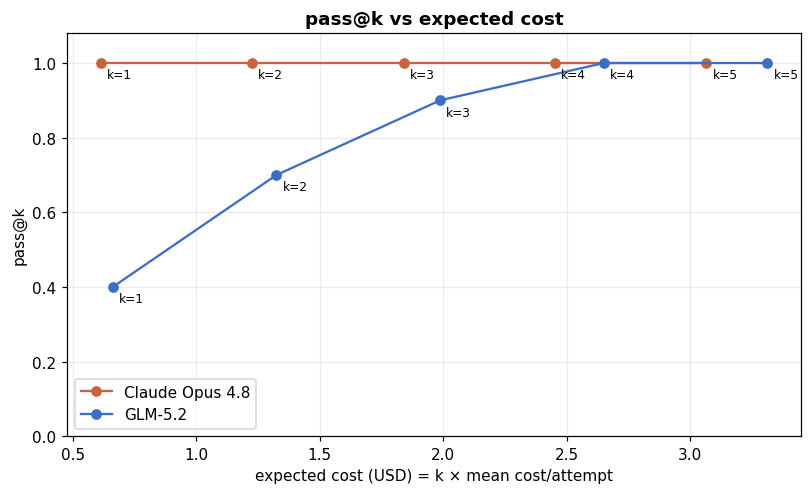

NOTE: GLM cost is indicative when run via Ollama Cloud (subscription billing).


In [10]:
# The money chart: pass@k vs expected $ spend. "If I'm willing to sample k times,
# what does a passing fix cost?" — the decision an auto-fixer in CI actually makes.
if RAN2:
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    for k, m in RAN2.items():
        curve = m["aggregate"]["pass_at_k_vs_cost"]
        xs = [c["expected_cost_usd"] for c in curve]
        ys = [c["pass_at_k"] for c in curve]
        ax.plot(xs, ys, marker="o", color=COLOR(k), label=m["label"])
        for c in curve:
            ax.annotate(f"k={c['k']}", (c["expected_cost_usd"], c["pass_at_k"]),
                        textcoords="offset points", xytext=(4, -10), fontsize=8)
    ax.set_xlabel("expected cost (USD) = k × mean cost/attempt")
    ax.set_ylabel("pass@k"); ax.set_ylim(0, 1.08)
    ax.set_title("pass@k vs expected cost")
    ax.legend(); fig.tight_layout(); plt.show()
    print("NOTE: GLM cost is indicative when run via Ollama Cloud (subscription billing).")

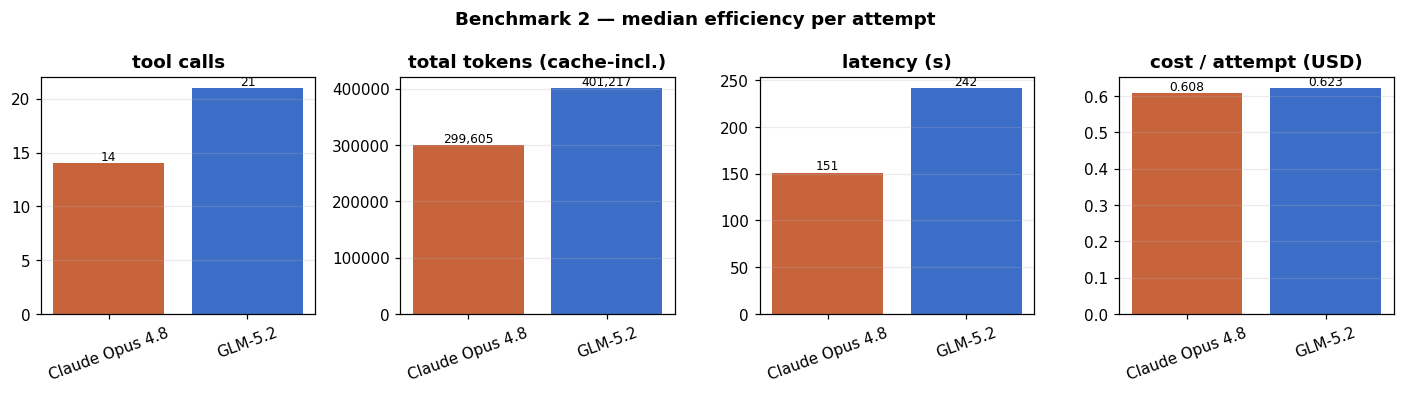

In [11]:
# Efficiency profile — medians across trials. Tool-calls/tokens (not steps) are the
# fair effort axis: Opus batches several tool calls into one step.
if b2 is not None:
    panels = [("median_tool_calls", "tool calls", "{:.0f}"),
              ("median_total_tokens", "total tokens (cache-incl.)", "{:,.0f}"),
              ("median_latency_s", "latency (s)", "{:.0f}"),
              ("median_cost_usd", "cost / attempt (USD)", "{:.3f}")]
    fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
    cols = [COLOR(k) for k in b2["key"]]
    for ax, (col, title, fmt) in zip(axes, panels):
        ax.bar(b2.index, b2[col], color=cols)
        ax.set_title(title)
        for i, v in enumerate(b2[col]):
            ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=8)
        ax.tick_params(axis="x", rotation=20); ax.grid(axis="x")
    fig.suptitle("Benchmark 2 — median efficiency per attempt", fontweight="bold")
    fig.tight_layout(); plt.show()

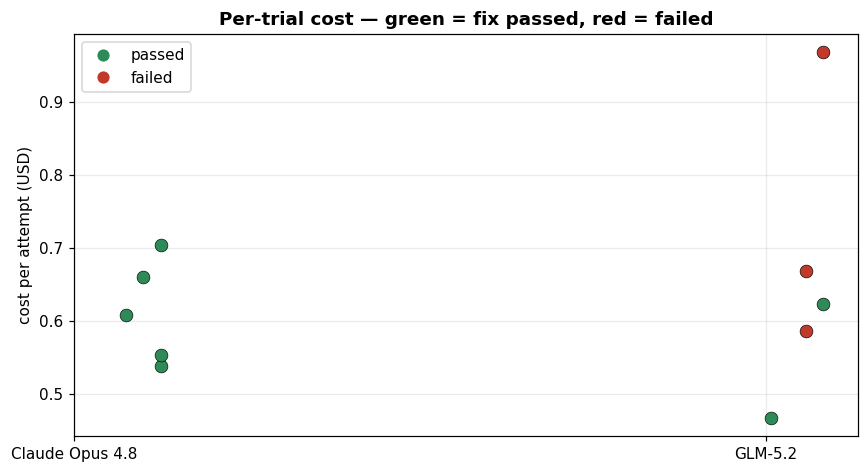

In [12]:
# Per-trial spread: cost of every attempt, green = passed, red = failed.
# Shows consistency, not just the median.
if RAN2:
    fig, ax = plt.subplots(figsize=(8, 4.4))
    labels = []
    for xi, (k, m) in enumerate(RAN2.items()):
        labels.append(m["label"])
        for t in m["trials"]:
            jitter = (hash(t.get("model_id", "")) % 7 - 3) / 30 + (id(t) % 5 - 2) / 40
            ax.scatter(xi + jitter, t["total_cost_usd"],
                       color=("#2E8B57" if t.get("success") else "#C0392B"),
                       edgecolor="k", linewidth=0.4, s=70, zorder=3)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_ylabel("cost per attempt (USD)")
    ax.set_title("Per-trial cost — green = fix passed, red = failed")
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([0], [0], marker="o", color="w", label="passed",
                              markerfacecolor="#2E8B57", markersize=9),
                       Line2D([0], [0], marker="o", color="w", label="failed",
                              markerfacecolor="#C0392B", markersize=9)])
    fig.tight_layout(); plt.show()

---
## Read-out

Fill in from the live numbers above (these are the points engineers will want):

- **Long-context retrieval (B1):** file-level F1 is the headline — can the model tell
  you which files to touch? Line-level recall on the *wide-blast* symbols is the real
  stress test of reading a 130k-token context.
- **Agentic reasoning (B2):** pass@1 and the pass@k curve say whether the model can
  actually *fix* a bug end-to-end; the pass@k-vs-cost chart says what that costs.
- **Efficiency:** tool-calls and tokens-per-attempt show *how* each model gets there
  (more iteration vs. fewer, sharper edits).
- **Cost caveat:** Opus costs are exact (prompt-cached); GLM via Ollama Cloud is
  subscription-billed, so its dollar figures are indicative.

Every number here is reproducible — the oracle and the pytest verdict are deterministic,
so re-running the benchmarks reproduces these results.

---
# 📊 Article figures — the cost-inversion story

Six self-contained, decision-grade charts built straight from the two result files,
designed to drop into the write-up. Each cell saves a 150-dpi PNG under `figures/`.

| Fig | The claim it proves |
|---|---|
| **1** | **The inversion** — same model, 3× cheaper per token yet 2.7× pricier per *fix*. |
| **2** | **Why** — Opus rents its context from cache; GLM re-pays full price every turn. |
| **3** | **History bloat** — GLM's billable input climbs each step; Opus stays flat (~2 tok). |
| **4** | **Analysis paralysis** — failed GLM runs drown in `read_file` and never run a test. |
| **5** | **Latency tail** — Opus stays tight (~151 s); GLM blows out to 587 s. |
| **6** | **Routing** — read-once → GLM, loop+write → Opus. |

In [13]:
# === Article figures: shared setup =========================================
# The six charts below are built straight from the two result files loaded above
# and back the specific claims in the write-up. Chart text is kept in English so the
# PNGs render cleanly without a Japanese font; each cell also saves a 150-dpi PNG
# under notebooks/figures/ ready to drop into the article.
import numpy as np

FIGS = Path("figures"); FIGS.mkdir(exist_ok=True)
OPUS_C, GLM_C = MODEL_COLORS["opus-4-8"], MODEL_COLORS["glm-5-2"]
WIN, LOSE, TIE = GLM_C, OPUS_C, "#9AA0A6"  # blue = GLM-favorable, orange = Opus-favorable

# List prices (USD / 1M tokens) + Anthropic cache multipliers — mirror
# blast_radius/config.py (Opus $5/$25, GLM $1.40/$4.40) and models.py.
PRICE = {"opus": {"inp": 5.0, "out": 25.0}, "glm": {"inp": 1.40, "out": 4.40}}
CACHE_READ_MULT, CACHE_WRITE_MULT = 0.10, 1.25


def savefig(fig, name):
    fig.savefig(FIGS / name, dpi=150, bbox_inches="tight", facecolor="white")


def median_trial(model):
    """The trial whose total_tokens is closest to the reported median."""
    med = model["aggregate"]["median_total_tokens"]
    return min(model["trials"], key=lambda t: abs(t["total_tokens"] - med))


def billed_input(t):
    """Cache-weighted input tokens you actually pay for (Anthropic pricing)."""
    return (t["total_input_tokens"]
            + CACHE_WRITE_MULT * t["total_cache_creation_tokens"]
            + CACHE_READ_MULT * t["total_cache_read_tokens"])


if single and debug:
    OP1, GL1 = single["models"]["opus-4-8"], single["models"]["glm-5-2"]
    OP2, GL2 = debug["models"]["opus-4-8"], debug["models"]["glm-5-2"]
    print("Article-figure data ready — PNGs will be saved to", FIGS.resolve())
else:
    print("Need both result files (latest.json + debug_loop_latest.json).")

Article-figure data ready — PNGs will be saved to C:\Users\dvall\Documents\skincare-coach\notebooks\figures


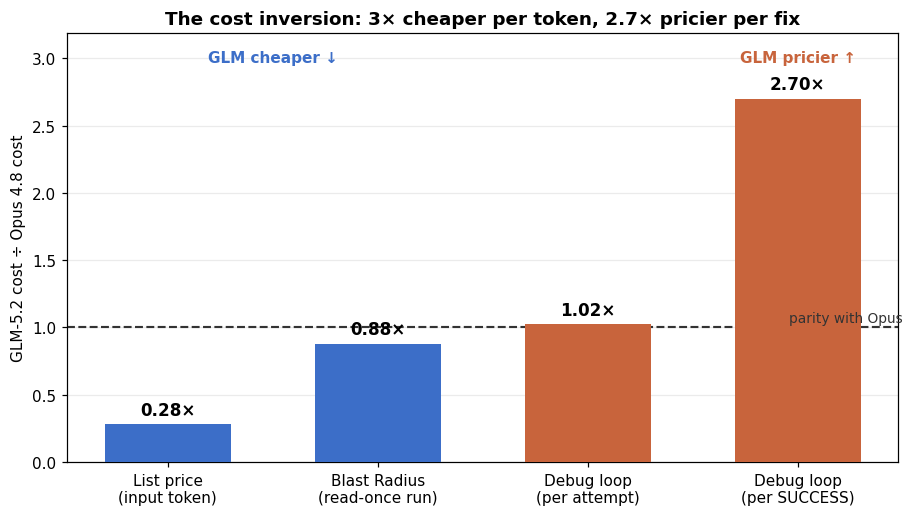

In [14]:
# FIG 1 — The cost inversion: GLM cost relative to Opus across task shapes.
# Bars below the parity line = GLM cheaper; above = GLM pricier. The same model
# crosses from "3× cheaper" (list price) to "2.7× pricier" (per successful fix).
if single and debug:
    a1, b1 = OP1["aggregate"], GL1["aggregate"]
    a2, b2 = OP2["aggregate"], GL2["aggregate"]
    labels = ["List price\n(input token)", "Blast Radius\n(read-once run)",
              "Debug loop\n(per attempt)", "Debug loop\n(per SUCCESS)"]
    ratios = [PRICE["glm"]["inp"] / PRICE["opus"]["inp"],
              b1["total_cost_usd"] / a1["total_cost_usd"],
              b2["median_cost_usd"] / a2["median_cost_usd"],
              b2["cost_per_pass_usd"] / a2["cost_per_pass_usd"]]
    fig, ax = plt.subplots(figsize=(8.4, 4.8))
    x = np.arange(len(labels))
    ax.bar(x, ratios, color=[WIN if r < 1 else LOSE for r in ratios], width=0.6, zorder=3)
    ax.axhline(1.0, color="#333", lw=1.4, ls="--", zorder=2)
    ax.text(len(labels) - 0.5, 1.02, "parity with Opus", ha="right", va="bottom",
            fontsize=9, color="#333")
    for xi, r in zip(x, ratios):
        ax.text(xi, r + 0.04, f"{r:.2f}×", ha="center", va="bottom",
                fontsize=11, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("GLM-5.2 cost ÷ Opus 4.8 cost")
    ax.set_ylim(0, max(ratios) * 1.18)
    ax.set_title("The cost inversion: 3× cheaper per token, 2.7× pricier per fix")
    ax.grid(axis="x")
    ax.text(0.5, max(ratios) * 1.10, "GLM cheaper ↓", ha="center", color=WIN,
            fontsize=10, fontweight="bold")
    ax.text(3.0, max(ratios) * 1.10, "GLM pricier ↑", ha="center", color=LOSE,
            fontsize=10, fontweight="bold")
    fig.tight_layout(); savefig(fig, "fig1_cost_inversion.png"); plt.show()

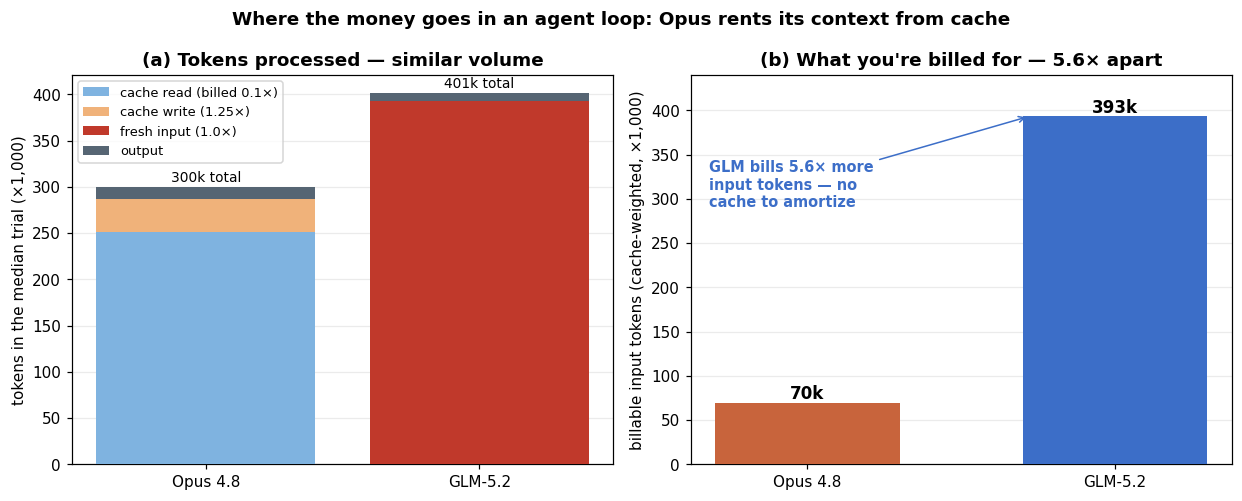

In [15]:
# FIG 2 — Why the inversion happens: cache vs full-price history (debug-loop economics).
if single and debug:
    ot, gt = median_trial(OP2), median_trial(GL2)
    fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6))

    # (a) raw token volume, stacked by billing class
    ax = axes[0]; models = ["Opus 4.8", "GLM-5.2"]; k = 1e3
    fresh = np.array([ot["total_input_tokens"], gt["total_input_tokens"]]) / k
    cwrite = np.array([ot["total_cache_creation_tokens"],
                       gt["total_cache_creation_tokens"]]) / k
    cread = np.array([ot["total_cache_read_tokens"],
                      gt["total_cache_read_tokens"]]) / k
    out = np.array([ot["total_output_tokens"], gt["total_output_tokens"]]) / k
    b = np.zeros(2)
    for vals, lab, col in [(cread, "cache read (billed 0.1×)", "#7FB3E0"),
                           (cwrite, "cache write (1.25×)", "#F0B27A"),
                           (fresh, "fresh input (1.0×)", "#C0392B"),
                           (out, "output", "#566573")]:
        ax.bar(models, vals, bottom=b, label=lab, color=col, zorder=3); b += vals
    ax.set_ylabel("tokens in the median trial (×1,000)")
    ax.set_title("(a) Tokens processed — similar volume")
    ax.legend(fontsize=8.5, loc="upper left"); ax.grid(axis="x")
    for i, tot in enumerate(b):
        ax.text(i, tot + 6, f"{tot:.0f}k total", ha="center", fontsize=9)

    # (b) what you actually pay for: cache-weighted billable input tokens
    ax = axes[1]
    billed = np.array([billed_input(ot), billed_input(gt)]) / k
    ax.bar(models, billed, color=[OPUS_C, GLM_C], width=0.6, zorder=3)
    for i, v in enumerate(billed):
        ax.text(i, v + 4, f"{v:.0f}k", ha="center", fontsize=11, fontweight="bold")
    ax.set_ylabel("billable input tokens (cache-weighted, ×1,000)")
    ax.set_title("(b) What you're billed for — 5.6× apart")
    ax.set_ylim(0, billed[1] * 1.12); ax.grid(axis="x")
    ax.annotate(f"GLM bills {billed[1] / billed[0]:.1f}× more\ninput tokens — no\ncache to amortize",
                xy=(0.72, billed[1]), xytext=(-0.32, billed[1] * 0.74), ha="left",
                fontsize=9.5, color=GLM_C, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=GLM_C))
    fig.suptitle("Where the money goes in an agent loop: Opus rents its context from cache",
                 fontweight="bold")
    fig.tight_layout(); savefig(fig, "fig2_cache_economics.png"); plt.show()

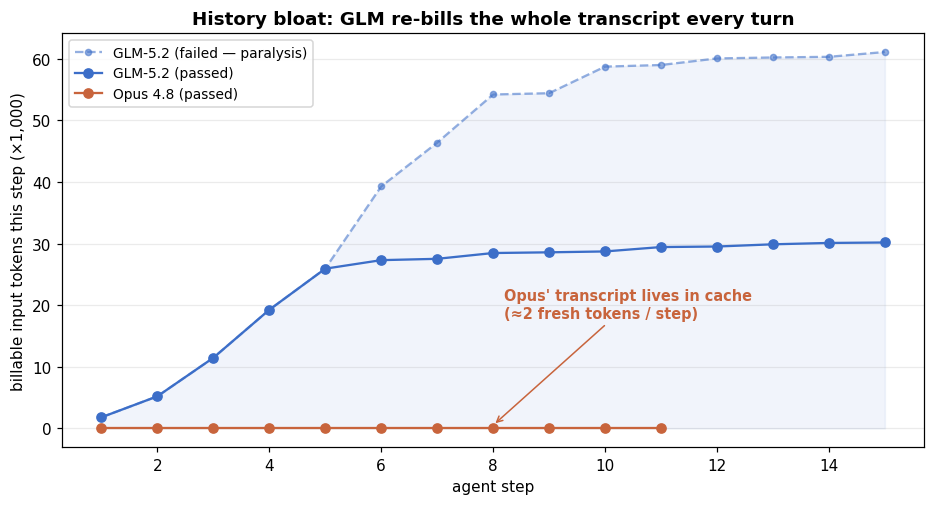

In [16]:
# FIG 3 — History bloat: billable input tokens per agent step.
if single and debug:
    op_pass = next(t for t in OP2["trials"] if t["success"])
    gl_pass = next(t for t in GL2["trials"] if t["success"])
    gl_fail = next(t for t in GL2["trials"] if not t["success"])

    def _steps(t):
        s = t["steps"]
        return [d["step"] for d in s], [d["input_tokens"] / 1e3 for d in s]

    fig, ax = plt.subplots(figsize=(8.6, 4.7))
    xs, ys = _steps(gl_fail)
    ax.plot(xs, ys, marker="o", ms=4, color=GLM_C, ls="--", alpha=0.55,
            label="GLM-5.2 (failed — paralysis)")
    ax.fill_between(xs, ys, color=GLM_C, alpha=0.07)
    xs, ys = _steps(gl_pass)
    ax.plot(xs, ys, marker="o", color=GLM_C, label="GLM-5.2 (passed)")
    xs, ys = _steps(op_pass)
    ax.plot(xs, ys, marker="o", color=OPUS_C, label="Opus 4.8 (passed)")
    ax.set_xlabel("agent step")
    ax.set_ylabel("billable input tokens this step (×1,000)")
    ax.set_title("History bloat: GLM re-bills the whole transcript every turn")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.annotate("Opus' transcript lives in cache\n(≈2 fresh tokens / step)",
                xy=(8, 0.5), xytext=(8.2, 18), fontsize=9.5, color=OPUS_C,
                fontweight="bold", arrowprops=dict(arrowstyle="->", color=OPUS_C))
    ax.legend(loc="upper left", fontsize=9); ax.grid(axis="x")
    fig.tight_layout(); savefig(fig, "fig3_history_bloat.png"); plt.show()

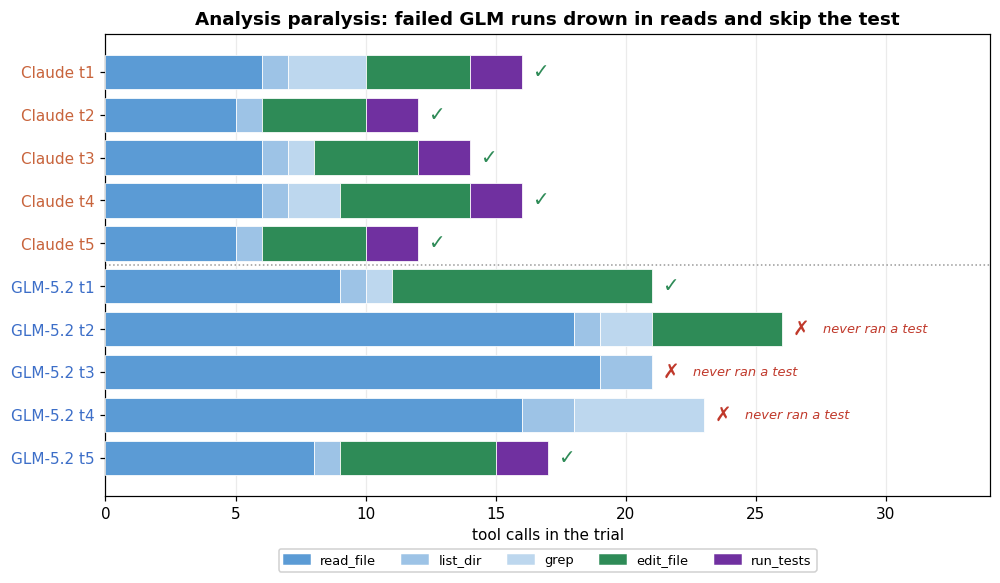

In [17]:
# FIG 4 — Analysis paralysis: tool-call composition per trial (pass = ✓, fail = ✗).
if single and debug:
    rows = []
    for key, model in [("opus-4-8", OP2), ("glm-5-2", GL2)]:
        short = model["label"].split()[0]
        for i, t in enumerate(model["trials"], 1):
            rows.append((f"{short} t{i}", key, t))
    cats = [("read_file", "#5B9BD5"), ("list_dir", "#9DC3E6"), ("grep", "#BDD7EE"),
            ("edit_file", "#2E8B57"), ("run_tests", "#7030A0")]
    fig, ax = plt.subplots(figsize=(9.2, 5.4))
    y = np.arange(len(rows))[::-1]
    for yi, (lab, key, t) in zip(y, rows):
        left = 0
        for cat, col in cats:
            v = t["n_tool_calls"].get(cat, 0)
            if v:
                ax.barh(yi, v, left=left, color=col, zorder=3, edgecolor="white", lw=0.5)
                left += v
        ok = t["success"]
        ax.text(left + 0.4, yi, "✓" if ok else "✗", va="center", fontsize=13,
                fontweight="bold", color="#2E8B57" if ok else "#C0392B")
        if t["n_run_tests_calls"] == 0 and not ok:
            ax.text(left + 1.6, yi, "never ran a test", va="center", fontsize=8.5,
                    color="#C0392B", style="italic")
    ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows])
    for tick, (_, key, _t) in zip(ax.get_yticklabels(), rows):
        tick.set_color(OPUS_C if key == "opus-4-8" else GLM_C)
    ax.set_xlim(0, max(t["n_tool_calls_total"] for _, _, t in rows) + 8)
    ax.set_xlabel("tool calls in the trial")
    ax.set_title("Analysis paralysis: failed GLM runs drown in reads and skip the test")
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for _, c in cats]
    ax.legend(handles, [c for c, _ in cats], ncol=5, fontsize=8.5,
              loc="upper center", bbox_to_anchor=(0.5, -0.10), framealpha=0.9)
    ax.axhline(4.5, color="#999", lw=1, ls=":"); ax.grid(axis="y")
    fig.tight_layout(); savefig(fig, "fig4_analysis_paralysis.png"); plt.show()

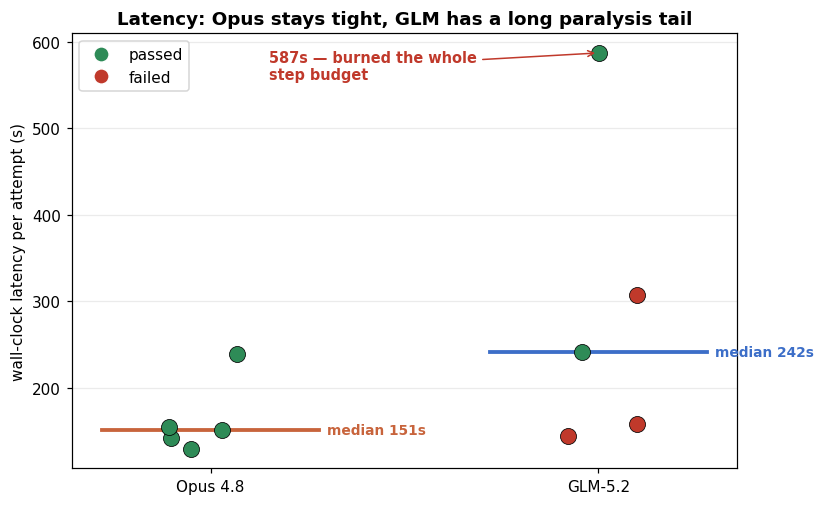

In [18]:
# FIG 5 — Latency spread across trials, including the 587s blow-up.
if single and debug:
    fig, ax = plt.subplots(figsize=(7.6, 4.7))
    for xi, (key, model) in enumerate([("opus-4-8", OP2), ("glm-5-2", GL2)]):
        lat = [t["total_latency_s"] for t in model["trials"]]
        ok = [t["success"] for t in model["trials"]]
        jit = (np.random.default_rng(xi).random(len(lat)) - 0.5) * 0.22
        for j, (l, s) in enumerate(zip(lat, ok)):
            ax.scatter(xi + jit[j], l, s=110, zorder=3, edgecolor="k", lw=0.5,
                       color="#2E8B57" if s else "#C0392B")
        med = model["aggregate"]["median_latency_s"]
        c = OPUS_C if key == "opus-4-8" else GLM_C
        ax.plot([xi - 0.28, xi + 0.28], [med, med], color=c, lw=2.5, zorder=2)
        ax.text(xi + 0.30, med, f"median {med:.0f}s", va="center", fontsize=9,
                color=c, fontweight="bold")
    worst = max(GL2["trials"], key=lambda t: t["total_latency_s"])
    ax.annotate(f"{worst['total_latency_s']:.0f}s — burned the whole\nstep budget",
                xy=(1, worst["total_latency_s"]),
                xytext=(0.15, worst["total_latency_s"] - 30), fontsize=9.5,
                color="#C0392B", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="#C0392B"))
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Opus 4.8", "GLM-5.2"])
    ax.set_ylabel("wall-clock latency per attempt (s)")
    ax.set_title("Latency: Opus stays tight, GLM has a long paralysis tail")
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([0], [0], marker="o", color="w", label="passed",
                              markerfacecolor="#2E8B57", markersize=10),
                       Line2D([0], [0], marker="o", color="w", label="failed",
                              markerfacecolor="#C0392B", markersize=10)],
              loc="upper left")
    ax.grid(axis="x")
    fig.tight_layout(); savefig(fig, "fig5_latency_spread.png"); plt.show()

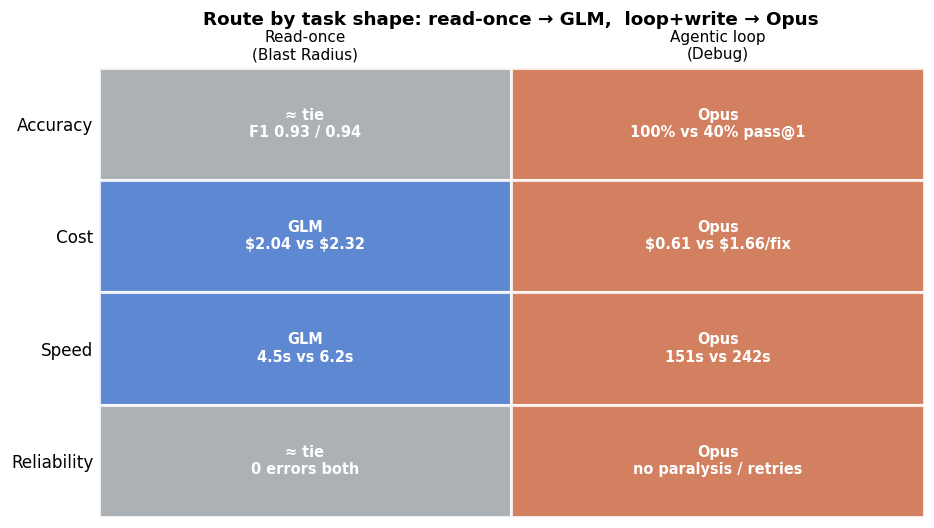

In [19]:
# FIG 6 — Routing scorecard: who wins which task shape.
if single and debug:
    a1, b1 = OP1["aggregate"], GL1["aggregate"]
    a2, b2 = OP2["aggregate"], GL2["aggregate"]
    metrics = ["Accuracy", "Cost", "Speed", "Reliability"]
    cols = ["Read-once\n(Blast Radius)", "Agentic loop\n(Debug)"]
    d = "\\$"  # literal dollar sign (a bare $ triggers matplotlib mathtext)
    grid = [
        [("tie", f"≈ tie\nF1 {b1['file']['macro']['f1']:.2f} / {a1['file']['macro']['f1']:.2f}"),
         ("opus", "Opus\n100% vs 40% pass@1")],
        [("glm", f"GLM\n{d}{b1['total_cost_usd']:.2f} vs {d}{a1['total_cost_usd']:.2f}"),
         ("opus", f"Opus\n{d}{a2['cost_per_pass_usd']:.2f} vs {d}{b2['cost_per_pass_usd']:.2f}/fix")],
        [("glm", f"GLM\n{b1['latency_s_mean']:.1f}s vs {a1['latency_s_mean']:.1f}s"),
         ("opus", f"Opus\n{a2['median_latency_s']:.0f}s vs {b2['median_latency_s']:.0f}s")],
        [("tie", "≈ tie\n0 errors both"), ("opus", "Opus\nno paralysis / retries")],
    ]
    cmap = {"glm": GLM_C, "opus": OPUS_C, "tie": TIE}
    fig, ax = plt.subplots(figsize=(8.6, 4.9))
    ax.set_xlim(0, 2); ax.set_ylim(0, 4); ax.invert_yaxis()
    ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(cols, fontsize=10)
    ax.set_yticks([0.5, 1.5, 2.5, 3.5]); ax.set_yticklabels(metrics, fontsize=11)
    ax.xaxis.tick_top()
    for r in range(4):
        for c in range(2):
            win, txt = grid[r][c]
            ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=cmap[win], alpha=0.82,
                                       edgecolor="white", lw=2))
            ax.text(c + 0.5, r + 0.5, txt, ha="center", va="center", color="white",
                    fontsize=9.5, fontweight="bold")
    ax.set_title("Route by task shape: read-once → GLM,  loop+write → Opus",
                 fontweight="bold", pad=28)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0); ax.grid(False)
    fig.tight_layout(); savefig(fig, "fig6_routing_scorecard.png"); plt.show()